In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix

In [3]:
iris = sns.load_dataset("iris")

In [4]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
encoder = LabelEncoder()
iris["species"] = encoder.fit_transform(iris["species"])

In [6]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df = iris[["sepal_length", "petal_width", "species"]]

In [8]:
df.head()

,sepal_length,petal_width,species
0,5.1,0.2,0
1,4.9,0.2,0
2,4.7,0.2,0
3,4.6,0.2,0
4,5.0,0.2,0


In [9]:
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [11]:
X_train.shape, X_test.shape

((120, 2), (30, 2))

In [12]:
clf = LogisticRegression(multi_class="multinomial")

In [13]:
clf.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial')

In [14]:
y_pred = clf.predict(X_test)

In [15]:
print(accuracy_score(y_test, y_pred))

0.9666666666666667


In [16]:
pd.DataFrame(confusion_matrix(y_test, y_pred))

,0,1,2
0,12,0,0
1,0,8,0
2,0,1,9


In [17]:
query = np.array([[2.4, 4.5]])
clf.predict_proba(query)

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[6.92154783e-08, 5.62544098e-04, 9.99437387e-01]])

In [18]:
clf.predict(query)

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([2])

In [19]:
query = np.array([[1.4, 2.5]])
clf.predict_proba(query)

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.22053128, 0.45346722, 0.32600149]])

In [20]:
clf.predict(query)

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [21]:
from mlxtend.plotting import plot_decision_regions

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


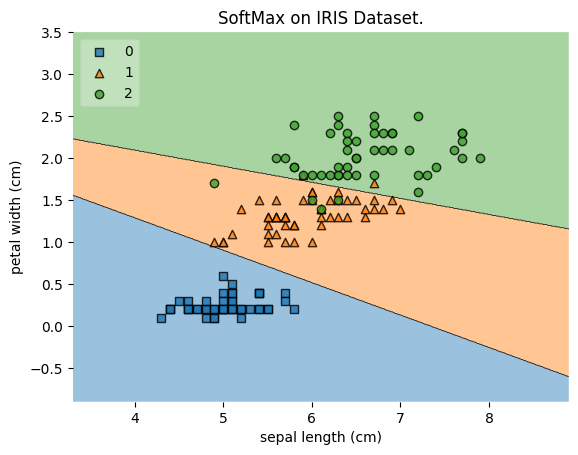

In [22]:
plot_decision_regions(X.values, y.values, clf, legend=2)

plt.xlabel("sepal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("SoftMax on IRIS Dataset.")

plt.show()